<a href="https://colab.research.google.com/github/vtu30522/Supradeep-Innolift_internship/blob/main/day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Drive and  Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
df = pd.read_csv('/content/drive/MyDrive/track_2/creditcard.csv')

print("Dataset Shape:", df.shape)
df.head()
df.info()
df.isnull().sum()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17  

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Check Fraud vs Non-Fraud Transactions

In [8]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


Separate Features and Target

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

Scale Time and Amount Columns

In [10]:
scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(
    X[['Time', 'Amount']]
)
joblib.dump(
    scaler,
    '/content/drive/MyDrive/track_2/scaler.pkl'
)

['/content/drive/MyDrive/track_2/scaler.pkl']

Split Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Training Model 1 – Random Forest

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Random Forest Evaluation Report

In [13]:
print("===== RANDOM FOREST REPORT =====")

print(classification_report(
    y_test,
    rf_pred
))
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

===== RANDOM FOREST REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy : 0.9995962220427653
Precision: 0.9995828694262612
Recall   : 0.9995962220427653
F1 Score : 0.9995819032776061


Random Forest Confusion Matrix

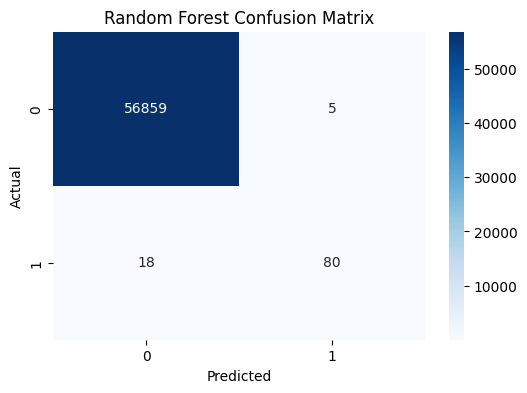

In [14]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    '/content/drive/MyDrive/track_2/rf_confusion_matrix.png'
)

plt.show()

Train Model 2 – Logistic Regression

In [15]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

logistic Regression Evaluation Report

In [16]:
print("===== LOGISTIC REGRESSION REPORT =====")

print(classification_report(
    y_test,
    lr_pred
))
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

===== LOGISTIC REGRESSION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy : 0.9991573329588147
Precision: 0.9990915062313275
Recall   : 0.9991573329588147
F1 Score : 0.9991041423931677


Logistic Regression:Confusion matrix

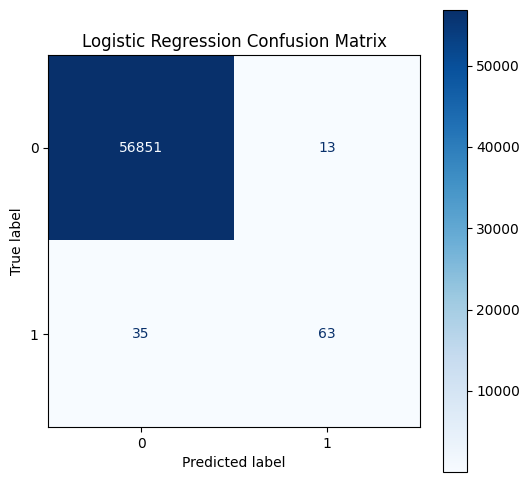

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")

plt.savefig("logistic_regression_confusion_matrix.png")

plt.show()

Creating Comparison Table

In [20]:
comparison = pd.DataFrame({
    'Accuracy':[rf_accuracy, lr_accuracy],
    'Precision':[rf_precision, lr_precision],
    'Recall':[rf_recall, lr_recall],
    'F1 Score':[rf_f1, lr_f1]
},
index=[
    'Random Forest',
    'Logistic Regression'
])

print(comparison)
comparison.to_csv(
    '/content/drive/MyDrive/track_2/comparison.csv'
)

                     Accuracy  Precision    Recall  F1 Score
Random Forest        0.999596   0.999583  0.999596  0.999582
Logistic Regression  0.999157   0.999092  0.999157  0.999104


 Comparison Graph

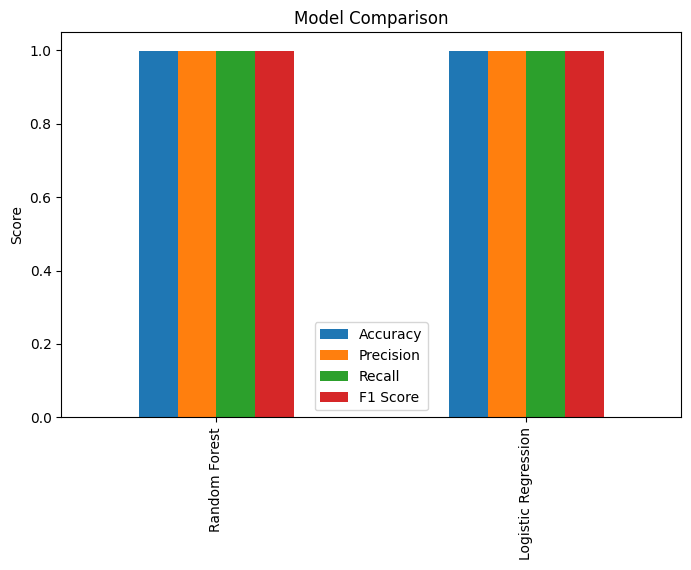

In [21]:
comparison.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")

plt.savefig(
    '/content/drive/MyDrive/track_2/model_comparison.png'
)

plt.show()

Selecting Best Model

In [22]:
if rf_f1 > lr_f1:
    best_model = rf_model
    best_name = "Random Forest"
    best_score = rf_f1
else:
    best_model = lr_model
    best_name = "Logistic Regression"
    best_score = lr_f1
    joblib.dump(
    best_model,
    '/content/drive/MyDrive/track_2/best_model.pkl'
)

Best Model

In [23]:
print("Best Model :", best_name)
print("Best F1 Score :", best_score)

Best Model : Random Forest
Best F1 Score : 0.9995819032776061
